#Data setup

In [4]:
import os
import sys
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt



In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Using:", device)

PyTorch: 2.13.0+cu130
CUDA build: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Using: cuda


In [6]:
sys.executable

'/mnt/c/users/omerb/OneDrive/omer/Projects/ai/.venv/bin/python'

In [24]:
input_file_path = "./data/input.txt"
if not os.path.exists(input_file_path):
    data_url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    with open(input_file_path, 'w', encoding='utf-8') as f:
        f.write(requests.get(data_url).text)

In [29]:
input_file_path2 = "./data/input2.txt"
if not os.path.exists(input_file_path):
    data_url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/openwebtext/input.txt'
    with open(input_file_path, 'w', encoding='utf-8') as f:
        f.write(requests.get(data_url).text)

In [30]:
wdata = open(input_file_path,'r',encoding='utf-8').read()
iwdata = open(input_file_path2,'r',encoding='utf-8').read()

In [28]:
n = len(wdata)
raw_train_data = wdata[:int(n*0.9)]
raw_eval_data = wdata[int(n*0.9):]
print(n)
ni = len(iwdata)
iraw_train_data = iwdata[:int(n*0.9)]
iraw_eval_data = iwdata[int(n*0.9):]
print(ni)

1115394
14


In [10]:




#-----------------------------------------------------------------------------------
class Utf8Tokenizer(object):
    def __init__(self):
        self.dvocub = 256
    def tokenize(self, data):
       """
       Takes all of our data and spits out a huge data of tokens which is a list of numbers
       """ 
       return torch.tensor(list(data.encode("utf-8")))
    def detokenize(self, tokens):
        """
        Takes a list of tokens and converts to a string
        """
        return bytes(tokens).decode("utf-8", errors="replace")

#-----------------------------------------------------------------------------------
class SUtfTokenizer(object):
    """
    This one uses the smart algorithm
    """
    def __init__(self, initdata):
        self.utf8 = Utf8Tokenizer()
        actual_data = self.utf8.tokenize(initdata)
        self.a = actual_data
        actual_data = sorted(set(actual_data.tolist()))
    
        self.tokenize_dict = dict()
        self.detokenize_dict = dict()

        for i,n in enumerate(actual_data):
            self.tokenize_dict[n] = i
            self.detokenize_dict[i] = n
        self.dvocub = len(self.tokenize_dict)
        
    def tokenize(self, data):
        byte_tokens = self.utf8.tokenize(data).tolist()
        return torch.tensor([self.tokenize_dict[t] for t in byte_tokens], dtype=torch.long)
    def detokenize(self, tokens):
        if isinstance(tokens, torch.Tensor):
            tokens = tokens.detach().cpu().tolist()
        tokens = [self.detokenize_dict[t] for t in tokens]
        return self.utf8.detokenize(tokens)
#-----------------------------------------------------------------------------------
class Embedding(nn.Module):
    """
    Embeds vocub in the linear space
    """
    def __init__(self, dvocub, dembedding):
        
        super().__init__()
        self.dvocub = dvocub
        self.dembedding = dembedding
        self.embed = nn.Embedding(dvocub, dembedding)
    
    def forward(self,x):
        return self.embed(x)
    
#------------------------------------------------------------------------------------
class PositionalEmbedding(nn.Module):
    """
    Just holds the vector offset we add
        """
    def __init__(self, dcontext, dembedding):
        super().__init__()
        self.offset = nn.Parameter(torch.randn(dcontext, dembedding))
    
    def forward(self,x):
        #x has shape batch,context,dembedding
        return self.offset[:x.shape[1]]
    

"""
As a prep for the transformer block, let's repeat how it works


tokens->vocub->embeddings->embed+position->(attention_heads= xQ is the query matrix, xK is the key matrix. Their rows
are the questions/keys. Then (xQ)(xK)^t has (i,j) how xj answers xi. Then if j>i we mask, so we get upper triangular.
Then we concanate, then layer norm, then add to x. So

just does the heads part

Parameters-
context
dembedding 
dcorrelation
    Q,K will be (embed,correlation)
dperhead
    V will be (correlation, dperhead)
"""
#-------------------------------------------------------------------------------------
class AttentionHead(nn.Module):
    def __init__(self, dembedding, dcorrelation,dperhead, name="AttentionHead"):
        super().__init__()
        self.name = name
        self.dembedding = dembedding
        self.dcorrelation = dcorrelation #this is the correlation_space
        self.dperhead = dperhead
        self.Q = nn.Linear(dembedding, dcorrelation, bias = False)
        self.K = nn.Linear(dembedding, dcorrelation, bias = False)
        self.V = nn.Linear(dembedding,dperhead, bias = False)
        
        maxcontext = 1024
        upper_triangular = torch.tensor([[float("-inf") if i<j else 0 for j in range(maxcontext) ] for i in range(maxcontext)])
        bupper_triangular = upper_triangular.unsqueeze(0)
        self.register_buffer("mask", bupper_triangular)


    def forward(self,x):
        """
        x.shape = (batch,context, dembedding)
        """
        assert(x.shape[2] == self.dembedding)
        context = x.shape[1]
        xQ = self.Q(x)
        xK = self.K(x)
        xV = self.V(x)
        #these have shape 
        #in training: (batch, context, dcorrelation\dperhead)
        #in inference:
        #b = batch, c,d = context, k = korrelation
        xQxKt = torch.einsum("bck,bdk->bcd", xQ, xK)
        nxQxKt = xQxKt * self.dcorrelation**(-0.5)
        
        masked_xQxKt = nxQxKt + self.mask[:,:context,:context] #broadcast
        probs = masked_xQxKt.softmax(dim=-1)
        #shape is (Batch,context,context) with (i,j) is how j answers i
        changes = torch.einsum("bcd,bdh->bch", probs, xV)
        #if self.trianing: batch, context, hidden
        #if inference: context, hidden
        return changes
        
"""
Parameters-
context
heads
dembedding
dcorrelation
dperhead

x=x+(projection(heads(layer(x)))).
x = x+(ffn(layer(x))).
Here both layer, ffn are per token-vector
"""
#-------------------------------------------------------------------------------------
class TransformerBlock(nn.Module):
    def __init__(self, context, dheads, dembedding, dcorrelation, dperhead):
        super().__init__()

        self.context = context
        self.dheads = dheads
        self.dembedding= dembedding
        self.dcorrelation = dcorrelation
        self.dperhead = dperhead

        self.LN1 = nn.LayerNorm(dembedding)
        self.heads = nn.ModuleList()
        for i in range(dheads):
            head = AttentionHead(dembedding,dcorrelation, dperhead)
            self.heads.append(head)
        self.projection = nn.Linear(dperhead*dheads , self.dembedding)

        self.ffn = nn.Sequential(nn.LayerNorm(dembedding), nn.Linear(dembedding, 4*dembedding), nn.Tanh(), nn.Linear(4*dembedding,dembedding))
    
    def forward(self,x):
        #in training, x.shape = batch, context, dembed
        #in inference, x = context, dembed
        batch = x.shape[0]
        xcontext= x.shape[1]
        LN1x = self.LN1(x)
        heads_x = torch.stack([head(LN1x) for head in self.heads],dim=-1)
        #in training each of those head(LN1x) has shape batch,context,hidden,heads
        heads_x = heads_x.view(batch, xcontext, self.dperhead*self.dheads)
        x = x + self.projection(heads_x)
        #in training has shape batch, context, dembedding

        x = x + self.ffn(x)
        #in training has shape batch, context, dembedding
        return x
    
#------------------------------------------------------------------------------------
class Transformer(nn.Module):
    def __init__(self, dvocub, context, dheads, dembedding, dcorrelation, dperhead, blocks = 1):
        super().__init__()
        self.dvocub, self.context, self.dheads, self.dembedding, self.dcorrelation, self.dperhead, self.blocks = dvocub, context, dheads, dembedding, dcorrelation, dperhead, blocks

        self.embedding = Embedding(dvocub, dembedding)
        self.position_shift = PositionalEmbedding(context, dembedding)
        self.blocks = nn.ModuleList([TransformerBlock(context, dheads, dembedding, dcorrelation, dperhead) for i in range(blocks)])
        self.LN3 = nn.LayerNorm(self.dembedding)
        self.to_logits = nn.Linear(self.dembedding, self.dvocub)

    def forward(self, w):
        """
        x= embed(w)
        x = x + positional(x)
        for each block:
            x = block(x)
        (that block includes residula as well)
        
        now we grab the last vector, layernorm, and ffn into dvocub
        """
        x = self.embedding(w)
        x = x + self.position_shift(x)

        for b in self.blocks:
            x = b(x)
            #x.shape = batch, context, embedding
            #we now care about all outputs
        x = self.LN3(x)
        #Now the shape is (batch, context), embedding
        logits = self.to_logits(x)
        #Now the shape is (batch, context), dvocub
        return logits

    def probs(self,w):
        logits = self(w)
        return logits.softmax(dim=-1)


In [11]:
tokenizer = SUtfTokenizer(raw_train_data)
Xtr = tokenizer.tokenize(raw_train_data)
Xevl  = tokenizer.tokenize(raw_eval_data)
Ytr = Xtr[1:]
Yevl = Xevl[1:]
Xtr = Xtr[:-1]
Xevl = Xevl[:-1]

In [12]:
Xtr = Xtr.to(device)
Xevl = Xevl.to(device)
Ytr = Ytr.to(device)
Yevl = Yevl.to(device)

In [13]:
batchsize = 64
dvocub = tokenizer.dvocub
print(dvocub)
dheads = 4
dcontext = 128
dcorrelation = 32
dembedding = 128
dperhead = 32
dblock = 4

@torch.inference_mode()
def estimate_loss(data, targets, model, batches=10):
    model.eval()
    losses = []

    for _ in range(batches):
        starts = torch.randint(
            0, len(data) - dcontext,
            (batchsize,),
            device=data.device,
        )
        ix = starts[:, None] + torch.arange(
            dcontext, device=data.device
        )

        logits = model(data[ix])
        loss = F.cross_entropy(
            logits.flatten(0, 1),
            targets[ix].flatten(0, 1),
        )
        losses.append(loss)

    model.train()
    return torch.stack(losses).mean().item()



65


In [14]:
from collections import defaultdict
import math

iterations = 10000
lre = torch.linspace(-8,-3,iterations)
lri = 2**lre
lri = [2**(-7) for i in range(iterations)]
lossi = []
evali = []
params = defaultdict(list)
tommy = Transformer(dvocub, dcontext, dheads, dembedding, dcorrelation, dperhead, dblock).to(device)
print("Finished intialization")
currper = 0.0
optimizer = torch.optim.AdamW(tommy.parameters(), lr=1e-4)
for i in range(iterations):
    
    ix = torch.randint(0, len(Xtr[:-dcontext]), (batchsize,), device = device)
    ix = ix.unsqueeze(1) + torch.arange(dcontext, device=device)#shape (batch,1) + (context,1)
    xtr = Xtr[ix]
    ytr = Ytr[ix]
    y = tommy(xtr)
    #y now has shape batch,context,dvocub
    #ytr has shape batch,context
    loss = F.cross_entropy(y.flatten(0,1), ytr.flatten(0,1))

    #Now we gradient
    # for p in tommy.parameters():
    #     p.grad = None
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    # with torch.no_grad():
    #     for p in tommy.parameters():
    #         p -= p.grad * lri[i]
    newcurrper = float(i)/iterations
    if newcurrper > currper+1./100:
        eval_loss = estimate_loss(Xevl, Yevl,tommy)
        evali.append(eval_loss)
        lossi.append(loss.item())
        print(newcurrper, f"train loss: {loss}", f" eval loss: {eval_loss}")
        currper = newcurrper
print(f"Initial losss should be {math.log(dvocub)}")


0.0101 train loss: 2.94301700592041  eval loss: 2.909144639968872
0.0202 train loss: 2.7040700912475586  eval loss: 2.7011775970458984
0.0302 train loss: 2.595705032348633  eval loss: 2.6162776947021484
0.0403 train loss: 2.532651662826538  eval loss: 2.5714657306671143
0.0504 train loss: 2.5032401084899902  eval loss: 2.5220935344696045
0.0605 train loss: 2.4754891395568848  eval loss: 2.4964587688446045
0.0706 train loss: 2.4717910289764404  eval loss: 2.4714229106903076
0.0806 train loss: 2.4623193740844727  eval loss: 2.440753936767578
0.0907 train loss: 2.4153661727905273  eval loss: 2.425283193588257
0.1008 train loss: 2.4030826091766357  eval loss: 2.3866918087005615
0.1109 train loss: 2.37506103515625  eval loss: 2.3728229999542236
0.121 train loss: 2.3403053283691406  eval loss: 2.3456807136535645
0.1311 train loss: 2.2900824546813965  eval loss: 2.324702262878418
0.1412 train loss: 2.2841267585754395  eval loss: 2.307762861251831
0.1513 train loss: 2.244037628173828  eval los

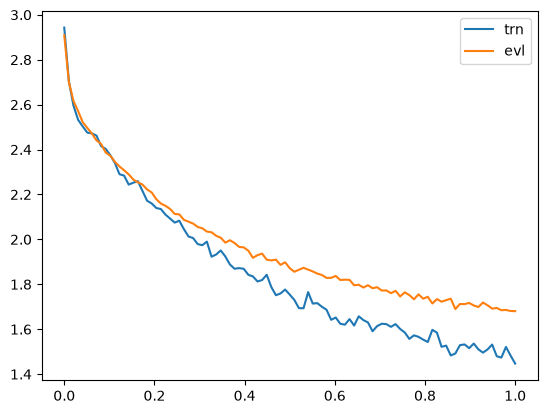

train: 1.4851149320602417
val:   1.682590126991272


In [17]:
import numpy as np
xloss = np.linspace(0,1,len(lossi))
xevl = np.linspace(0,1,len(evali))
plt.plot(xloss, lossi, label="trn")
plt.plot(xevl, evali, label="evl")
plt.legend()
plt.show()

print("train:", estimate_loss(Xtr, Ytr, tommy))
print("val:  ", estimate_loss(Xevl, Yevl, tommy))

In [16]:
estimate_loss(Xevl,Yevl)

TypeError: estimate_loss() missing 1 required positional argument: 'model'

# Inference time

In [ ]:
input = torch.tensor([0]).unsqueeze(0)
input = input.to(device)

In [ ]:
outputsize=400
T = torch.tensor(1, device = device)
currcontext = [0]
final = currcontext[:]
tommy.eval()
with torch.no_grad():
    for i in range(outputsize):
        input = torch.tensor(currcontext, device=device).unsqueeze(0) #adds fake batch dim
        input.to(device)
        newlogits = tommy(input)[0][-1] /T
        newprobs = newlogits.softmax(0)
        newbyte = torch.multinomial(newprobs,num_samples=1).item()
        currcontext.append(newbyte)
        final.append(newbyte)
        if len(currcontext) > dcontext:
            currcontext= currcontext[1:]
tommy.train()

Transformer(
  (embedding): Embedding(
    (embed): Embedding(65, 128)
  )
  (position_shift): PositionalEmbedding()
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (LN1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (heads): ModuleList(
        (0-3): 4 x AttentionHead(
          (Q): Linear(in_features=128, out_features=32, bias=False)
          (K): Linear(in_features=128, out_features=32, bias=False)
          (V): Linear(in_features=128, out_features=32, bias=False)
        )
      )
      (projection): Linear(in_features=128, out_features=128, bias=True)
      (ffn): Sequential(
        (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (1): Linear(in_features=128, out_features=512, bias=True)
        (2): Tanh()
        (3): Linear(in_features=512, out_features=128, bias=True)
      )
    )
  )
  (LN3): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (to_logits): Linear(in_features=128, out_fe

In [ ]:
print(tokenizer.detokenize(final))


Your mind, proud arrivates; yet you have purpose?
The great jest.

CORIOLANUS:
Not our heart arms,
And he famous my wonder clouds with is grave
Stanly.

FRIAR JOHN:
How besides, Mark of Grey, thee found gold
Till not haste.

LADY CAPULET:
Neither shall dishonour
Where thought were, throw thou better of death.
Yet you not this creature, that, God good, night,
This is my ilested in Bolingbroke as th


In [ ]:
named_params = tommy.named_parameters()

In [ ]:
ln = list(named_params)

In [ ]:
embed=ln[0][-1]
offset=ln[1][1]


In [ ]:
embed1=(embed[:, 1])
offset1 = offset[:, 0]


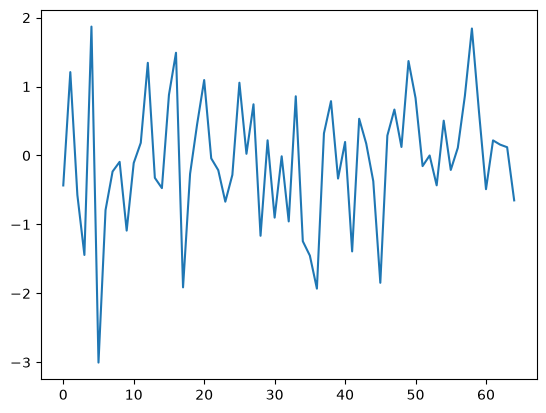

In [ ]:
plt.plot(embed1.detach())


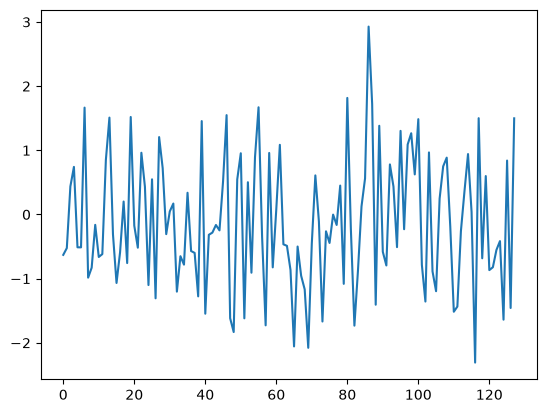

In [ ]:
plt.plot(offset1.detach())